In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from tqdm import tqdm

import pickle as pkl
import numpy as np
import pandas as pd
import geopandas as gpd

from numpy.random import Generator, MT19937
from collections import Counter

import torch 
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, jaccard_score

from neuralhydrology.modelzoo.ealstm import EALSTM
from neuralhydrology.utils.config import Config


In [3]:
run_dir = Path("/home/wuhlmann/BA/repo/lamah-ce_lstm/models/q_pred_landcover_0903_135428")
cfg = Config(run_dir / "config.yml")
# Initialize model with base paramters from config. 
ea_lstm = EALSTM(cfg=cfg)

# Load the trained weights into the model. 
weights_path = run_dir / f"model_epoch016.pt"
weights = torch.load(str(weights_path), map_location="cpu")
ea_lstm.load_state_dict(weights)


<All keys matched successfully>

In [4]:
sum(p.numel() for p in ea_lstm.parameters() if p.requires_grad) 

206849

In [5]:
state_dict = ea_lstm.state_dict()

### Inspect $i$

In [6]:
strata_ids = pd.read_table("/home/wuhlmann/BA/repo/lamah-ce_lstm/data/splits_incl_landcover/strata_ids.txt", header=0, sep=",")
strata_ids.set_index("ID", inplace=True)

lamah_gdf = gpd.read_file("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/3_shapefiles/Basins_B.shp")
lamah_gdf.set_index("ID", inplace=True)
lamah_gdf["strata"] = strata_ids["names"]
lamah_gdf.sort_index(ascending=True, inplace=True)

In [7]:
with open("/home/wuhlmann/BA/data/processed_data/evaluation/input_gate.p", "rb") as f: 
    input_gate_dict = pkl.load(f)

input_gate_dict = dict(sorted(input_gate_dict.items(), key=lambda item: int(item[0])))

In [8]:
attributes = [
	#geomorph - unargueable
	"area_calc", # how much water is available *
	"elev_mean", # how much snow, how much energy *
	"elev_ran", # how variable is the catchment
	"slope_mean", # energy of surface runoff *(since mountains)

	#precipitation
	"p_mean", # influx *
	"et0_mean", # outflux *
	"arid_1", # there are some arid catchments (more et0 than p_mean)
	"p_season", # encode seasonal pattern *
	"hi_prec_fr", # how often do high prec events occur (days/yr with p > 5*p_mean) *
	"hi_prec_du", #*
	"lo_prec_fr", # how often do low prec events occur (days/yr with p < 1 mm/d) *
	"lo_prec_du", #*
	"frac_snow", # essential in mountainous catchments *

    #land cover - nice, since they are accurate over the catchment, and not averaged
	"agr_fra", # 
	"bare_fra", # 
	"forest_fra", # storage
	"glac_fra", # super rare case, and then not that important 
	"lake_fra", # storage, also quite rare
	"urban_fra", # * versieglung, an proxy for disturbance of natural waterways

	#vegetation - represent water storage, and also differences between summer and winter - choose lai or ndvi, since they are correlated. And lai also has some info, about how many layers of vegetation there are. 
	"lai_max", 
	"lai_diff",
	"gvf_max",
	"gvf_diff",

	#soil - represent storage and also percolation speed
	"bedrk_dep", #*
	"soil_poros", #*
	"soil_condu", #*
	"sand_fra", #*
	"silt_fra", #*
	"clay_fra" #*
	]

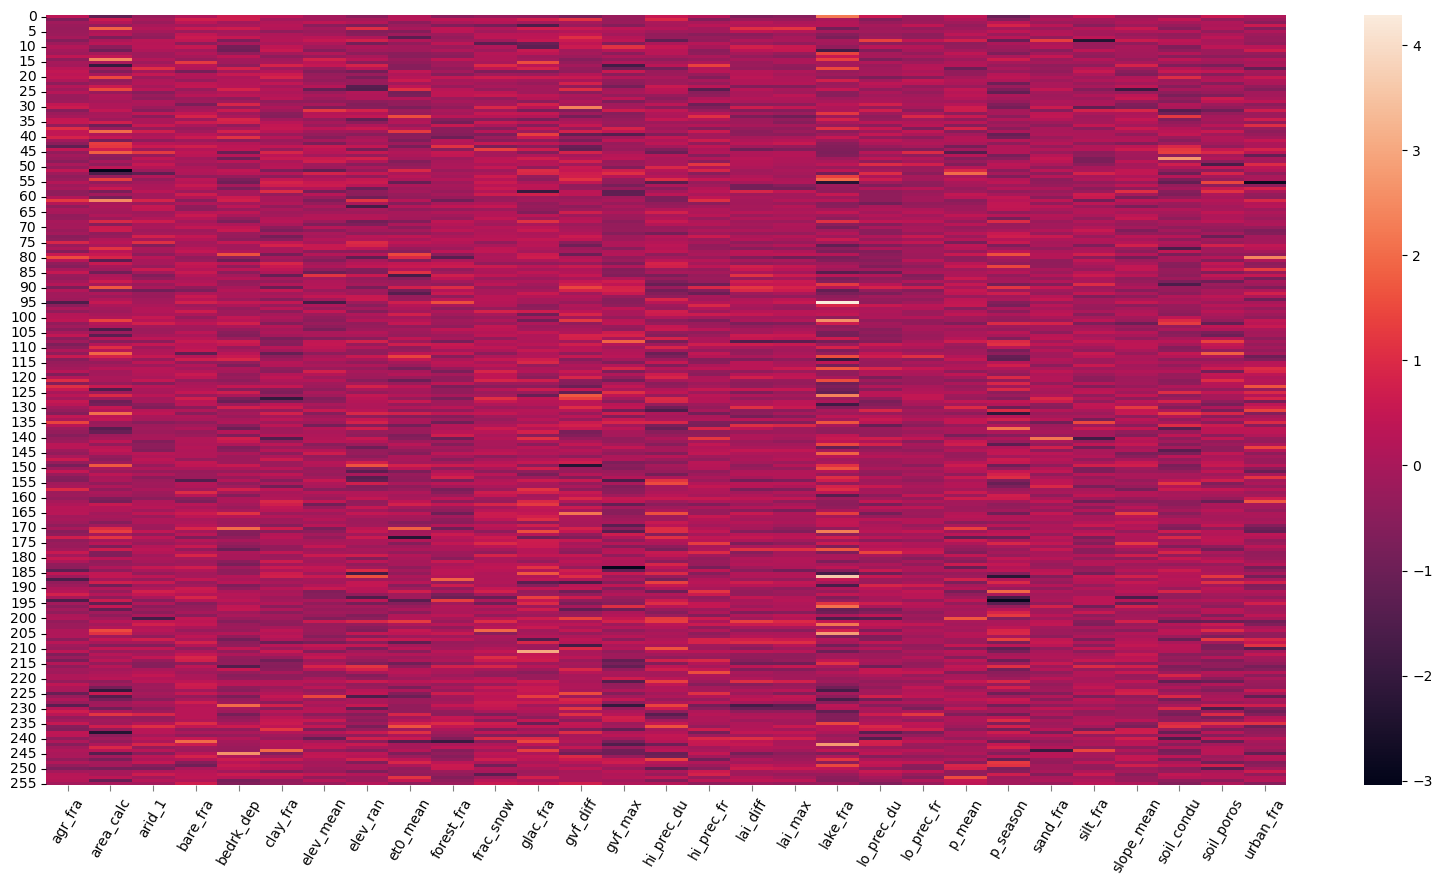

In [9]:
fig, ax = plt.subplots(1,1, figsize=(20,10))
i_weights = ea_lstm.input_gate.weight.detach().numpy()
i_weights_df = pd.DataFrame(data=i_weights, columns=sorted(attributes))
sns.heatmap(i_weights_df, ax=ax)
ax.tick_params(axis='x', length=4, color="gray", labelrotation=60) 
    

In [10]:
attr_abs_mean_weight = pd.DataFrame(data =abs(i_weights).mean(axis=0), index=sorted(attributes))

In [11]:
attr_abs_mean_weight.sort_values(by=0, ascending=False)

,0
lake_fra,0.639572
area_calc,0.512117
p_season,0.506889
gvf_diff,0.452231
glac_fra,0.447851
hi_prec_du,0.443307
elev_ran,0.438892
gvf_max,0.429247
soil_condu,0.426120
urban_fra,0.403718


In [12]:
key_vectors = []

for b in input_gate_dict.keys():

	key_vectors.append(torch.sigmoid(torch.tensor(input_gate_dict[b])).detach().numpy())

key_vector_df = pd.DataFrame(data=key_vectors, index=lamah_gdf.index)

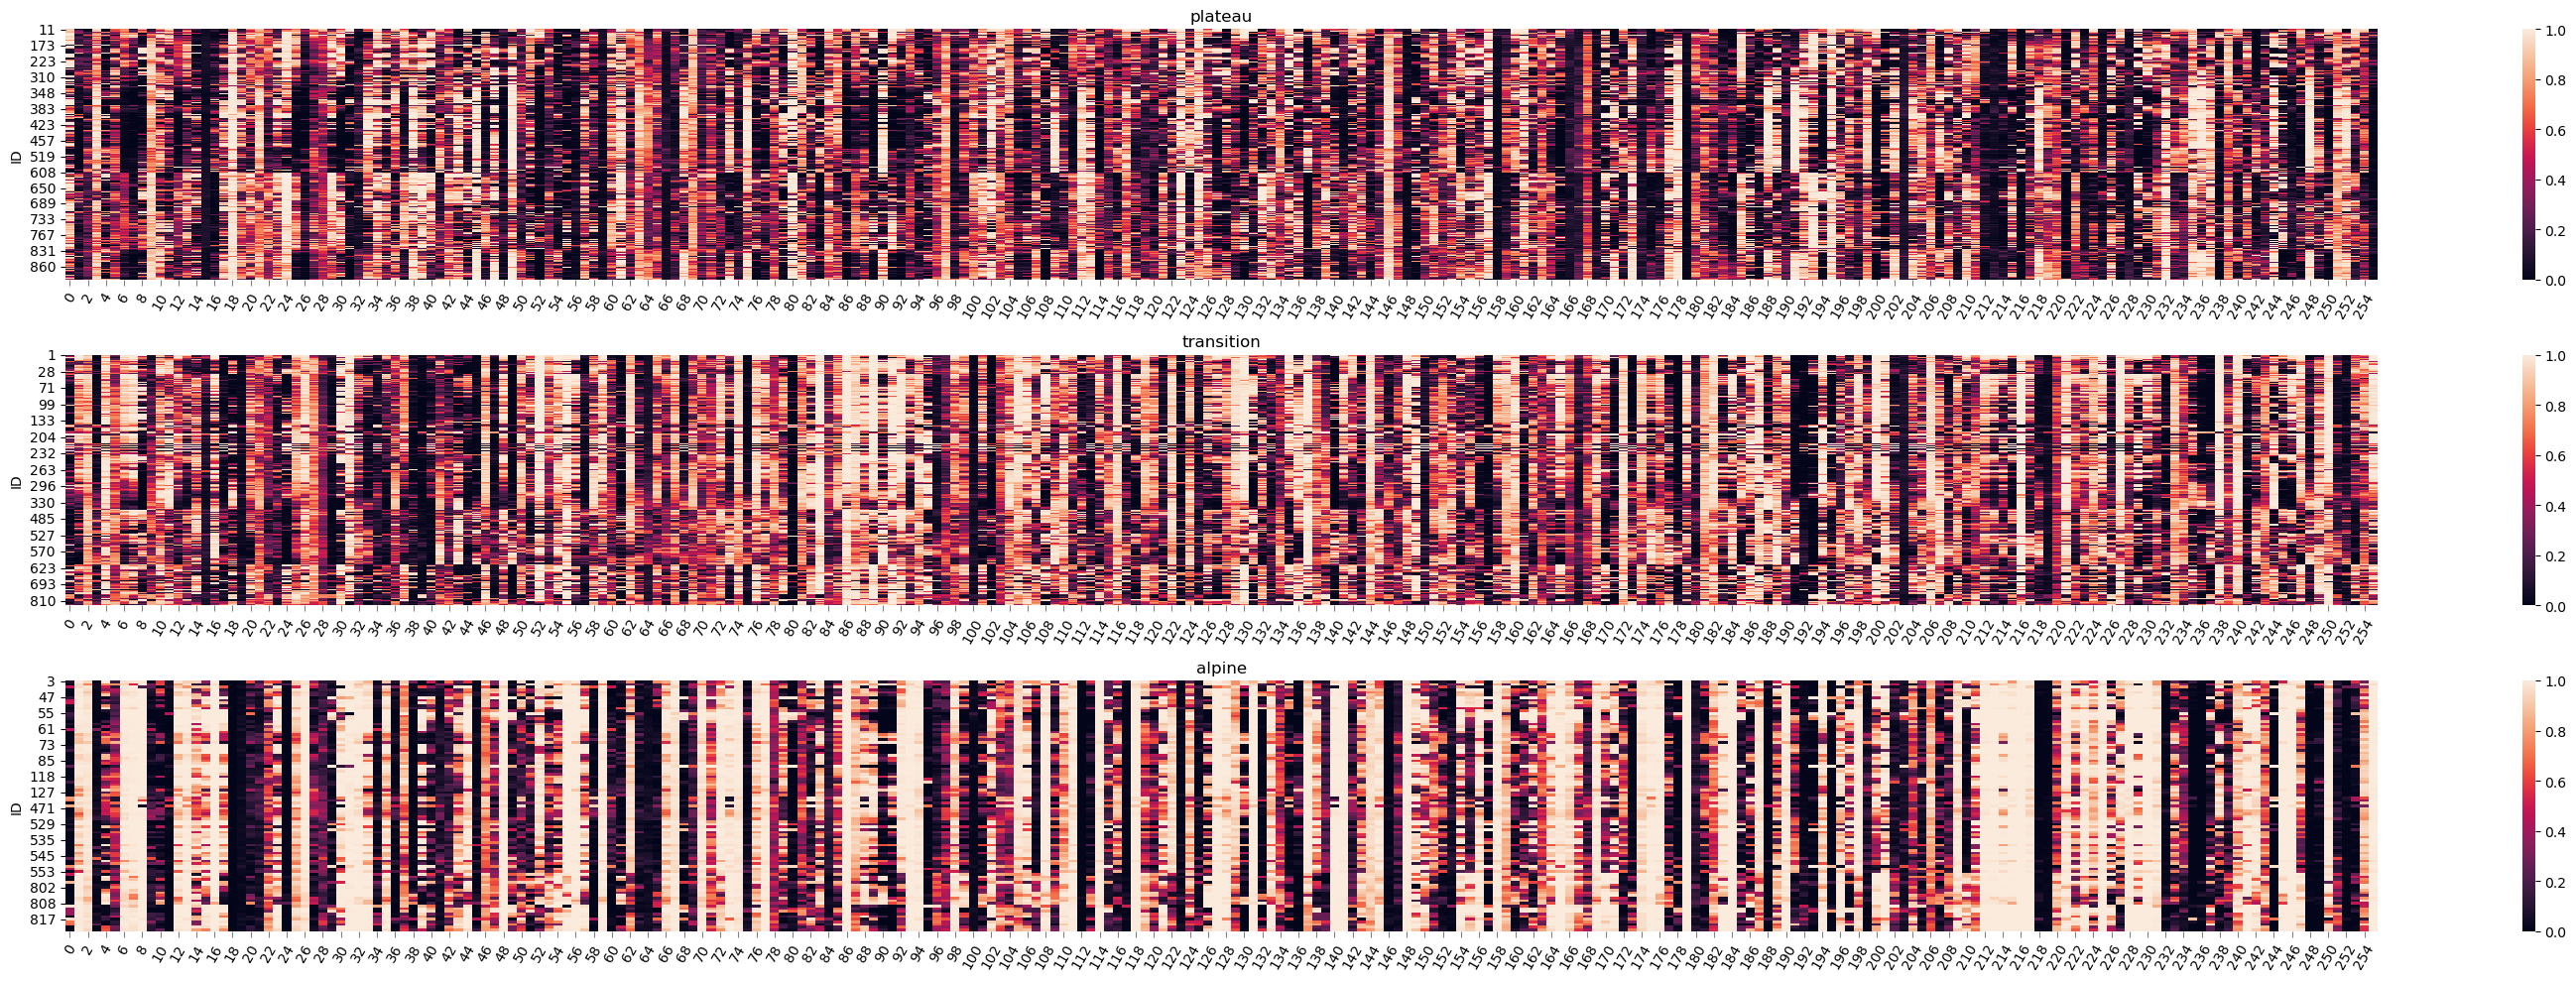

In [13]:
fig, axs = plt.subplots(3,1, figsize=(30,10))

for ax, strata in zip(axs, ["plateau", "transition", "alpine"]):

	select_strata = strata_ids.index[strata_ids["names"] == strata].tolist()
	sns.heatmap(key_vector_df.loc[select_strata], ax=ax)
	ax.tick_params(axis='x', length=4, color="gray", labelrotation=60) 
	ax.set_title(strata)

plt.tight_layout()

### Cluster keys

In [14]:
rng_seed = 1277
rng = Generator(MT19937(rng_seed))

100%|██████████| 100/100 [00:18<00:00,  5.33it/s]


Text(0.5, 1.0, 's_scores')

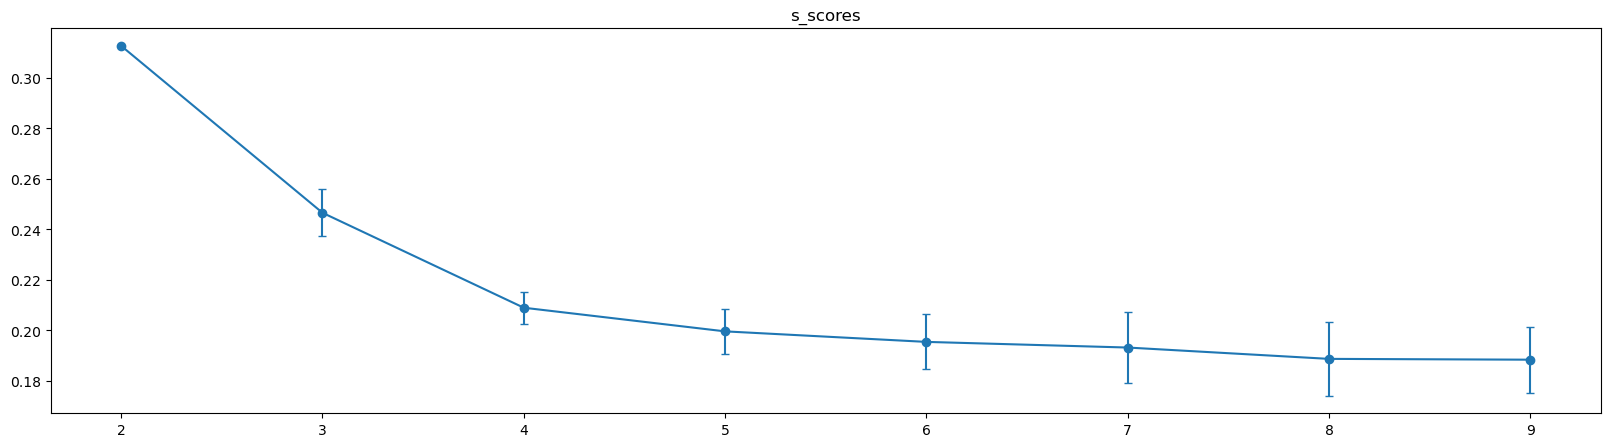

In [15]:
n_seeds = 100

seeds = list(rng.integers(0, 1000, n_seeds))
s_scores = np.zeros([n_seeds,10]) 

for i in tqdm(range(0,n_seeds)):

	seed = seeds[i]

	for k in range(2,10):

		# Test for k-means.
		labels = KMeans(k,random_state=seed).fit_predict(key_vector_df)
		s_scores[i,k] = silhouette_score(key_vector_df,labels) # higher is better
		
avg_s_scores = s_scores.mean(axis=0)[2:]

std_s_scores = s_scores.std(axis=0)[2:]

fig, axs = plt.subplots(1,1, figsize=(20,5))

axs.errorbar(range(2,10), avg_s_scores, yerr=std_s_scores, marker="o", capsize=3)

axs.set_title("s_scores")

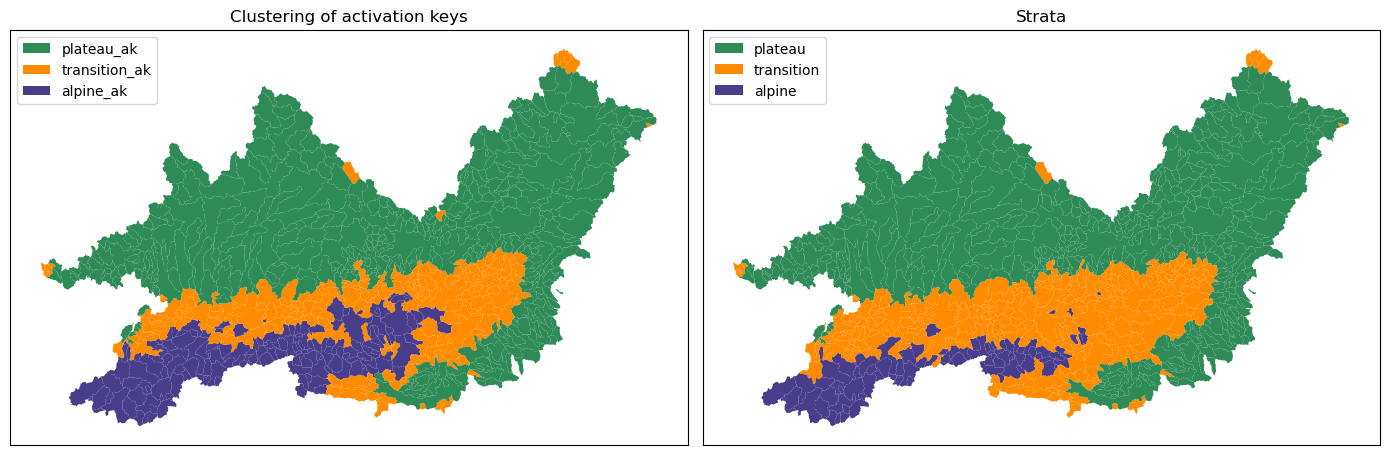

In [22]:
seed = seeds[np.where(s_scores[:,3] == Counter(s_scores[:,3]).most_common(1)[0][0])[0][0]] 

kmeans = KMeans(3, random_state=seed)

cluster = kmeans.fit_predict(key_vector_df)

# 1. remap 
label_dict = {0: 1, 1: 0, 2: 2}
cluster_remapped = list(map(lambda x: label_dict[x], cluster))

# 2. labels
name_dict = {0: "plateau", 1: "transition", 2: "alpine"}
cluster_named = list(map(lambda x: name_dict[x], cluster_remapped))

# 3. colors
color_dict = {"plateau": "seagreen", "transition": "darkorange", "alpine": "darkslateblue"}
cluster_colors = list(map(lambda x: color_dict[x], cluster_named))
strata_colors = list(map(lambda x: color_dict[name_dict[x]], strata_ids["0"]))

lamah_gdf["cluster"] = cluster_named

# plot
fig, axs = plt.subplots(1,2, figsize=(14,7))
legend_elements = [
    Patch(facecolor="seagreen",      label="plateau_ak"),
    Patch(facecolor="darkorange",    label="transition_ak"),
    Patch(facecolor="darkslateblue", label="alpine_ak"),
]

lamah_gdf.plot(ax=axs[0], color=cluster_colors)
axs[0].legend(handles=legend_elements, loc="upper left")
axs[0].set_title("Clustering of activation keys")

legend_elements = [
    Patch(facecolor="seagreen",      label="plateau"),
    Patch(facecolor="darkorange",    label="transition"),
    Patch(facecolor="darkslateblue", label="alpine"),
]

lamah_gdf.plot(ax=axs[1], color=strata_colors)
axs[1].legend(handles=legend_elements, loc="upper left")
axs[1].set_title("Strata")

axs[0].set_xticks([])
axs[0].set_yticks([])

axs[1].set_xticks([])
axs[1].set_yticks([])

plt.tight_layout()

In [23]:
fig.savefig("/home/wuhlmann/BA/repo/lamah-ce_lstm/results/CA/activation_key_clustering.png", dpi=300)

In [18]:
lamah_gdf["cluster"].to_csv("/home/wuhlmann/BA/data/processed_data/CA/ak_clusters.csv", sep=";")

In [19]:
s_v = lamah_gdf['strata'].values
#np.random.shuffle(s_v)

print(f"jaccard score {jaccard_score(s_v, lamah_gdf['cluster'], average=None)}")

jaccard score [0.55882353 0.96344086 0.70886076]


In [20]:
np.random.shuffle(lamah_gdf["strata"].values)